In [2]:
import pandas as pd
import requests
import matplotlib.pyplot as plt

print("pandas:", pd.__version__)
print("requests:", requests.__version__)

pandas: 3.0.5
requests: 2.34.2


In [3]:
import requests

url = "https://api.energy-charts.info/price"

response = requests.get(url)

print(response.status_code)

200


In [4]:
data = response.json()
print(data.keys())

dict_keys(['license_info', 'unix_seconds', 'price', 'unit', 'deprecated'])


In [5]:
for key, value in data.items():
    print(key, type(value))

license_info <class 'str'>
unix_seconds <class 'list'>
price <class 'list'>
unit <class 'str'>
deprecated <class 'bool'>


In [8]:
print(data["unix_seconds"][:5])
print(data["price"][:5])
print(data["unit"])

[1787090400, 1787091300, 1787092200, 1787093100, 1787094000]
[192.0, 179.12, 174.36, 160.92, 163.46]
EUR / MWh


In [9]:
print("Anzahl Zeitstempel:", len(data["unix_seconds"]))
print("Anzahl Preise:", len(data["price"]))

Anzahl Zeitstempel: 96
Anzahl Preise: 96


In [10]:
df_price = pd.DataFrame({
    "timestamp": pd.to_datetime(
        data["unix_seconds"],
        unit="s",
        utc=True
    ),
    "price": data["price"]
})

In [11]:
df_price.head()

,timestamp,price
0,2026-08-18 22:00:00+00:00,192.00
1,2026-08-18 22:15:00+00:00,179.12
2,2026-08-18 22:30:00+00:00,174.36
3,2026-08-18 22:45:00+00:00,160.92
4,2026-08-18 23:00:00+00:00,163.46


In [12]:
df_price.info()

<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype             
---  ------     --------------  -----             
 0   timestamp  96 non-null     datetime64[s, UTC]
 1   price      96 non-null     float64           
dtypes: datetime64[s, UTC](1), float64(1)
memory usage: 1.6 KB


In [13]:
print(df_price.dtypes)

timestamp    datetime64[s, UTC]
price                   float64
dtype: object


In [14]:
print("Start:", df_price["timestamp"].min())
print("Ende:", df_price["timestamp"].max())

Start: 2026-08-18 22:00:00+00:00
Ende: 2026-08-19 21:45:00+00:00


In [15]:
print(df_price["timestamp"].diff().value_counts().head(10))

timestamp
0 days 00:15:00    95
Name: count, dtype: int64


In [16]:
print(df_price.isna().sum())

timestamp    0
price        0
dtype: int64


In [17]:
df_price["price"].describe()

count     96.000000
mean     166.026458
std       27.604639
min      123.800000
25%      145.937500
50%      157.390000
75%      191.790000
max      221.780000
Name: price, dtype: float64

In [18]:
print(data["unix_seconds"][:5])
print(data["price"][:5])
print(data["unit"])

print("Anzahl Zeitstempel:", len(data["unix_seconds"]))
print("Anzahl Preise:", len(data["price"]))

df_price.head()
df_price.info()

print("Start:", df_price["timestamp"].min())
print("Ende:", df_price["timestamp"].max())

print(df_price["timestamp"].diff().value_counts().head(10))

print(df_price.isna().sum())

[1787090400, 1787091300, 1787092200, 1787093100, 1787094000]
[192.0, 179.12, 174.36, 160.92, 163.46]
EUR / MWh
Anzahl Zeitstempel: 96
Anzahl Preise: 96
<class 'pandas.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype             
---  ------     --------------  -----             
 0   timestamp  96 non-null     datetime64[s, UTC]
 1   price      96 non-null     float64           
dtypes: datetime64[s, UTC](1), float64(1)
memory usage: 1.6 KB
Start: 2026-08-18 22:00:00+00:00
Ende: 2026-08-19 21:45:00+00:00
timestamp
0 days 00:15:00    95
Name: count, dtype: int64
timestamp    0
price        0
dtype: int64


In [19]:
url = "https://api.energy-charts.info/price"

params = {
    "bzn": "DE-LU"
}

response = requests.get(url, params=params)

print(response.status_code)
print(response.url)

200
https://api.energy-charts.info/price?bzn=DE-LU


In [20]:
data_de = response.json()

print(data_de.keys())

dict_keys(['license_info', 'unix_seconds', 'price', 'unit', 'deprecated'])


In [21]:
print(len(data_de["unix_seconds"]))

96


In [22]:
print(
    pd.to_datetime(
        data_de["unix_seconds"],
        unit="s",
        utc=True
    ).min()
)

print(
    pd.to_datetime(
        data_de["unix_seconds"],
        unit="s",
        utc=True
    ).max()
)

2026-08-18 22:00:00+00:00
2026-08-19 21:45:00+00:00


In [23]:
params = {
    "bzn": "DE-LU",
    "start": "2025-01-01",
    "end": "2025-02-01"
}

response = requests.get(
    "https://api.energy-charts.info/price",
    params=params
)

print(response.status_code)
print(response.url)

200
https://api.energy-charts.info/price?bzn=DE-LU&start=2025-01-01&end=2025-02-01


In [24]:
historical_data = response.json()

print(historical_data.keys())
print(len(historical_data["unix_seconds"]))

dict_keys(['license_info', 'unix_seconds', 'price', 'unit', 'deprecated'])
768


In [25]:
timestamps = pd.to_datetime(
    historical_data["unix_seconds"],
    unit="s",
    utc=True
)

print("Start:", timestamps.min())
print("Ende:", timestamps.max())

Start: 2024-12-31 23:00:00+00:00
Ende: 2025-02-01 22:00:00+00:00


In [26]:
params = {
    "bzn": "DE-LU",
    "start": "2025-01-01",
    "end": "2025-02-01"
}

response = requests.get(
    "https://api.energy-charts.info/price",
    params=params
)

print(response.status_code)
print(response.url)

200
https://api.energy-charts.info/price?bzn=DE-LU&start=2025-01-01&end=2025-02-01


In [27]:
historical_data = response.json()

print(historical_data.keys())
print("Anzahl:", len(historical_data["unix_seconds"]))

dict_keys(['license_info', 'unix_seconds', 'price', 'unit', 'deprecated'])
Anzahl: 768


In [28]:
timestamps = pd.to_datetime(
    historical_data["unix_seconds"],
    unit="s",
    utc=True
)

print("Start:", timestamps.min())
print("Ende:", timestamps.max())

Start: 2024-12-31 23:00:00+00:00
Ende: 2025-02-01 22:00:00+00:00


In [29]:
print(
    timestamps.diff().value_counts().head(10)
)

0 days 01:00:00    767
Name: count, dtype: int64


In [30]:
df_price = pd.DataFrame({
    "timestamp": pd.to_datetime(
        historical_data["unix_seconds"],
        unit="s",
        utc=True
    ),
    "price": historical_data["price"]
})

In [32]:
df_price.head()

,timestamp,price
0,2024-12-31 23:00:00+00:00,2.16
1,2025-01-01 00:00:00+00:00,1.60
2,2025-01-01 01:00:00+00:00,0.00
3,2025-01-01 02:00:00+00:00,-0.01
4,2025-01-01 03:00:00+00:00,-0.01


In [33]:
df_price.tail()

,timestamp,price
763,2025-02-01 18:00:00+00:00,162.98
764,2025-02-01 19:00:00+00:00,156.60
765,2025-02-01 20:00:00+00:00,145.24
766,2025-02-01 21:00:00+00:00,141.73
767,2025-02-01 22:00:00+00:00,131.74


In [34]:
print(df_price.shape)
print(df_price.dtypes)
print(df_price.isna().sum())
print(df_price["timestamp"].duplicated().sum())
print(df_price["timestamp"].diff().value_counts().head())

(768, 2)
timestamp    datetime64[s, UTC]
price                   float64
dtype: object
timestamp    0
price        0
dtype: int64
0
timestamp
0 days 01:00:00    767
Name: count, dtype: int64


In [35]:
df_price["price"].describe()

count    768.000000
mean     114.805977
std       59.174090
min       -1.010000
25%       85.890000
50%      115.720000
75%      137.965000
max      583.400000
Name: price, dtype: float64

In [40]:
df_price_ts = df_price.set_index("timestamp")
df_price_ts.head()

,price
timestamp,
2024-12-31 23:00:00+00:00,2.16
2025-01-01 00:00:00+00:00,1.60
2025-01-01 01:00:00+00:00,0.00
2025-01-01 02:00:00+00:00,-0.01
2025-01-01 03:00:00+00:00,-0.01


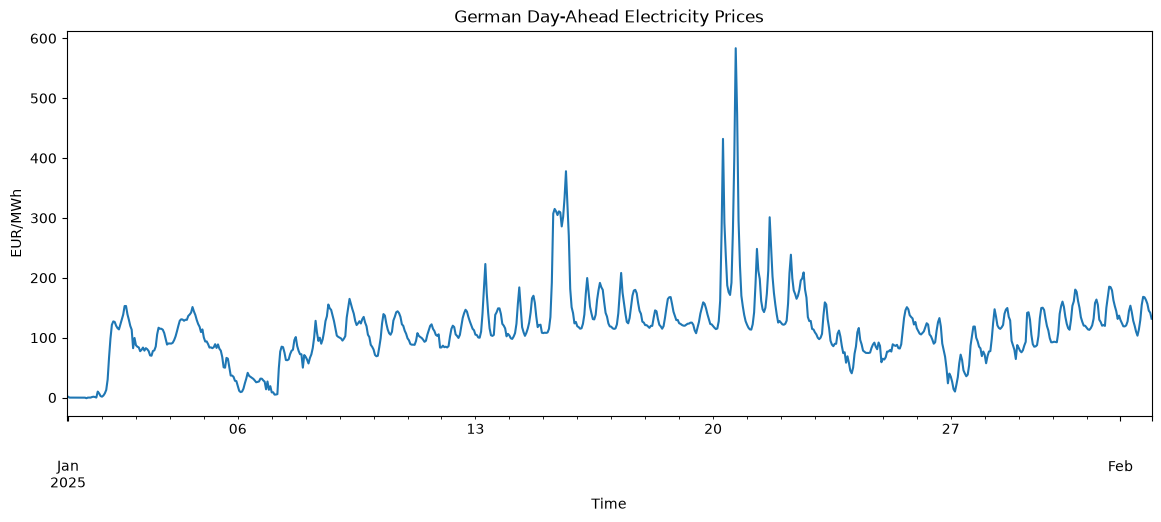

In [41]:
df_price_ts["price"].plot(
    figsize=(14, 5),
    title="German Day-Ahead Electricity Prices"
)

plt.ylabel("EUR/MWh")
plt.xlabel("Time")
plt.show()

#  API Test: public power 

In [42]:
url = "https://api.energy-charts.info/public_power"

response = requests.get(url)

print(response.status_code)
print(response.url)

200
https://api.energy-charts.info/public_power


In [43]:
power_data = response.json()

print(power_data.keys())

dict_keys(['unix_seconds', 'production_types', 'deprecated'])


In [44]:
for key, value in power_data.items():
    print(key, type(value))

unix_seconds <class 'list'>
production_types <class 'list'>
deprecated <class 'bool'>


In [45]:
print(df_price.shape)
print(df_price.dtypes)
print(df_price.isna().sum())
print(df_price["timestamp"].duplicated().sum())
print(df_price["timestamp"].diff().value_counts().head())

(768, 2)
timestamp    datetime64[s, UTC]
price                   float64
dtype: object
timestamp    0
price        0
dtype: int64
0
timestamp
0 days 01:00:00    767
Name: count, dtype: int64


In [46]:
url = "https://api.energy-charts.info/public_power"

response = requests.get(url)

print(response.status_code)
print(response.url)

power_data = response.json()

print(power_data.keys())

for key, value in power_data.items():
    print(key, type(value))

200
https://api.energy-charts.info/public_power
dict_keys(['unix_seconds', 'production_types', 'deprecated'])
unix_seconds <class 'list'>
production_types <class 'list'>
deprecated <class 'bool'>


In [47]:
print(len(power_data["unix_seconds"]))
print(len(power_data["production_types"]))
print(power_data["production_types"][:3])
print(type(power_data["production_types"][0]))

56
21
[{'name': 'Hydro pumped storage consumption', 'data': [-131.9, -18.7, -29.0, -26.9, -24.7, -24.6, -20.9, -133.5, -313.7, -312.1, -369.1, -389.8, -563.8, -560.9, -475.8, -296.4, -318.6, -359.0, -246.0, -157.0, -157.6, -132.1, -20.5, -16.1, -11.0, -8.4, -11.6, -11.3, -253.4, -10.5, -12.4, -9.4, -256.4, -479.5, -681.9, -1620.9, -207.1, -198.2, -1579.7, -1512.1, -571.1, -964.5, -2005.7, -2827.0, -2344.8, -2333.4, -2398.9, -2859.6, -2949.8, -3605.7, -4075.5, -4563.8, -4500.0, -4611.3, -4722.9, -4722.9]}, {'name': 'Cross border electricity trading', 'data': [3352.8, 3748.6, 3949.2, 3285.0, 2953.5, 2569.3, 2290.6, 2233.0, 1864.5, 1880.3, 2398.2, 2490.2, 2783.6, 2769.7, 2655.6, 2797.0, 3655.5, 3756.9, 3738.7, 3759.1, 4528.5, 4606.4, 4557.8, 4976.4, 5402.1, 6032.9, 6315.6, 5955.7, 7249.2, 7267.4, 7024.2, 6791.3, 6028.6, 5255.3, 5695.2, 4720.4, 1562.6, 796.9, 1055.8, 422.6, -737.2, -1499.4, -1022.3, -902.7, -2664.0, -3040.7, -3167.4, -3563.0, -4734.7, -4644.0, -4715.0, -4435.5, -6623.8, -6

In [48]:
from pprint import pprint

pprint(power_data["production_types"][:2])

[{'data': [-131.9,
           -18.7,
           -29.0,
           -26.9,
           -24.7,
           -24.6,
           -20.9,
           -133.5,
           -313.7,
           -312.1,
           -369.1,
           -389.8,
           -563.8,
           -560.9,
           -475.8,
           -296.4,
           -318.6,
           -359.0,
           -246.0,
           -157.0,
           -157.6,
           -132.1,
           -20.5,
           -16.1,
           -11.0,
           -8.4,
           -11.6,
           -11.3,
           -253.4,
           -10.5,
           -12.4,
           -9.4,
           -256.4,
           -479.5,
           -681.9,
           -1620.9,
           -207.1,
           -198.2,
           -1579.7,
           -1512.1,
           -571.1,
           -964.5,
           -2005.7,
           -2827.0,
           -2344.8,
           -2333.4,
           -2398.9,
           -2859.6,
           -2949.8,
           -3605.7,
           -4075.5,
           -4563.8,
           -4500

In [49]:
print(len(power_data["unix_seconds"]))
print(len(power_data["production_types"]))
print(type(power_data["production_types"][0]))
from pprint import pprint
pprint(power_data["production_types"][:2])

56
21
<class 'dict'>
[{'data': [-131.9,
           -18.7,
           -29.0,
           -26.9,
           -24.7,
           -24.6,
           -20.9,
           -133.5,
           -313.7,
           -312.1,
           -369.1,
           -389.8,
           -563.8,
           -560.9,
           -475.8,
           -296.4,
           -318.6,
           -359.0,
           -246.0,
           -157.0,
           -157.6,
           -132.1,
           -20.5,
           -16.1,
           -11.0,
           -8.4,
           -11.6,
           -11.3,
           -253.4,
           -10.5,
           -12.4,
           -9.4,
           -256.4,
           -479.5,
           -681.9,
           -1620.9,
           -207.1,
           -198.2,
           -1579.7,
           -1512.1,
           -571.1,
           -964.5,
           -2005.7,
           -2827.0,
           -2344.8,
           -2333.4,
           -2398.9,
           -2859.6,
           -2949.8,
           -3605.7,
           -4075.5,
           -456

In [50]:
for production_type in power_data["production_types"]:
    print(production_type["name"])

Hydro pumped storage consumption
Cross border electricity trading
Hydro Run-of-River
Biomass
Fossil brown coal / lignite
Fossil hard coal
Fossil oil
Fossil coal-derived gas
Fossil gas
Geothermal
Hydro water reservoir
Hydro pumped storage
Others
Waste
Wind offshore
Wind onshore
Solar
Load
Residual load
Renewable share of load
Renewable share of generation


In [51]:
len(power_data["unix_seconds"])

56

In [52]:
print(power_data["unix_seconds"][:10])

[1787090400, 1787091300, 1787092200, 1787093100, 1787094000, 1787094900, 1787095800, 1787096700, 1787097600, 1787098500]


In [53]:
power_timestamps = pd.to_datetime(
    power_data["unix_seconds"],
    unit="s",
    utc=True
)

print(power_timestamps[:10])

DatetimeIndex(['2026-08-18 22:00:00+00:00', '2026-08-18 22:15:00+00:00',
               '2026-08-18 22:30:00+00:00', '2026-08-18 22:45:00+00:00',
               '2026-08-18 23:00:00+00:00', '2026-08-18 23:15:00+00:00',
               '2026-08-18 23:30:00+00:00', '2026-08-18 23:45:00+00:00',
               '2026-08-19 00:00:00+00:00', '2026-08-19 00:15:00+00:00'],
              dtype='datetime64[s, UTC]', freq=None)


In [54]:
print(power_timestamps.diff().value_counts())

0 days 00:15:00    55
Name: count, dtype: int64


In [55]:
url = "https://api.energy-charts.info/public_power"

params = {
    "start": "2025-01-01",
    "end": "2025-02-01"
}

response = requests.get(
    url,
    params=params
)

print(response.status_code)
print(response.url)

200
https://api.energy-charts.info/public_power?start=2025-01-01&end=2025-02-01


In [56]:
historical_power = response.json()

print(historical_power.keys())
print(len(historical_power["unix_seconds"]))

dict_keys(['unix_seconds', 'production_types', 'deprecated'])
3072


In [57]:
historical_power_timestamps = pd.to_datetime(
    historical_power["unix_seconds"],
    unit="s",
    utc=True
)

print("Start:", historical_power_timestamps.min())
print("Ende:", historical_power_timestamps.max())

Start: 2024-12-31 23:00:00+00:00
Ende: 2025-02-01 22:45:00+00:00


In [58]:
print(
    historical_power_timestamps.diff().value_counts().head()
)

0 days 00:15:00    3071
Name: count, dtype: int64


In [59]:
for production_type in power_data["production_types"]:
    print(production_type["name"])

Hydro pumped storage consumption
Cross border electricity trading
Hydro Run-of-River
Biomass
Fossil brown coal / lignite
Fossil hard coal
Fossil oil
Fossil coal-derived gas
Fossil gas
Geothermal
Hydro water reservoir
Hydro pumped storage
Others
Waste
Wind offshore
Wind onshore
Solar
Load
Residual load
Renewable share of load
Renewable share of generation


In [60]:
url = "https://api.energy-charts.info/public_power"

params = {
    "start": "2025-01-01",
    "end": "2025-02-01"
}

response = requests.get(
    url,
    params=params
)

print(response.status_code)
print(response.url)

historical_power = response.json()

print(historical_power.keys())
print(len(historical_power["unix_seconds"]))

200
https://api.energy-charts.info/public_power?start=2025-01-01&end=2025-02-01
dict_keys(['unix_seconds', 'production_types', 'deprecated'])
3072


In [61]:
historical_power_timestamps = pd.to_datetime(
    historical_power["unix_seconds"],
    unit="s",
    utc=True
)

print("Start:", historical_power_timestamps.min())
print("Ende:", historical_power_timestamps.max())

print(
    historical_power_timestamps.diff().value_counts().head()
)

Start: 2024-12-31 23:00:00+00:00
Ende: 2025-02-01 22:45:00+00:00
0 days 00:15:00    3071
Name: count, dtype: int64


In [62]:
def get_production_type(data, name):
    for production_type in data["production_types"]:
        if production_type["name"] == name:
            return production_type["data"]
    
    raise ValueError(f"Production type '{name}' not found")

In [63]:
wind_offshore = get_production_type(
    historical_power,
    "Wind offshore"
)

wind_onshore = get_production_type(
    historical_power,
    "Wind onshore"
)

solar = get_production_type(
    historical_power,
    "Solar"
)

load = get_production_type(
    historical_power,
    "Load"
)

In [64]:
print("Wind offshore:", len(wind_offshore))
print("Wind onshore:", len(wind_onshore))
print("Solar:", len(solar))
print("Load:", len(load))

Wind offshore: 3072
Wind onshore: 3072
Solar: 3072
Load: 3072


In [65]:
print(wind_offshore[:5])
print(wind_onshore[:5])
print(solar[:5])
print(load[:5])

[2403.3, 2588.6, 2529.9, 2438.1, 2241.6]
[32103.5, 31965.5, 31964.1, 32025.2, 32378.0]
[0.0, 0.0, 0.0, 0.0, 0.0]
[48412.1, 47534.7, 47573.4, 47446.9, 47200.3]


In [66]:
df_power = pd.DataFrame({
    "timestamp": historical_power_timestamps,
    "wind_offshore": wind_offshore,
    "wind_onshore": wind_onshore,
    "solar": solar,
    "load": load
})

In [69]:
df_power.head()

,timestamp,wind_offshore,wind_onshore,solar,load
0,2024-12-31 23:00:00+00:00,2403.3,32103.5,0.0,48412.1
1,2024-12-31 23:15:00+00:00,2588.6,31965.5,0.0,47534.7
2,2024-12-31 23:30:00+00:00,2529.9,31964.1,0.0,47573.4
3,2024-12-31 23:45:00+00:00,2438.1,32025.2,0.0,47446.9
4,2025-01-01 00:00:00+00:00,2241.6,32378.0,0.0,47200.3


In [70]:
#Data Quality check 
print(df_power.shape)
print(df_power.dtypes)
print(df_power.isna().sum())
print(df_power["timestamp"].duplicated().sum())
print(df_power["timestamp"].diff().value_counts().head())

(3072, 5)
timestamp        datetime64[s, UTC]
wind_offshore               float64
wind_onshore                float64
solar                       float64
load                        float64
dtype: object
timestamp        0
wind_offshore    0
wind_onshore     0
solar            0
load             0
dtype: int64
0
timestamp
0 days 00:15:00    3071
Name: count, dtype: int64


In [71]:
df_power["timestamp"] = df_power["timestamp"].dt.tz_convert(
    "Europe/Berlin"
)

In [72]:
df_power.head()

,timestamp,wind_offshore,wind_onshore,solar,load
0,2025-01-01 00:00:00+01:00,2403.3,32103.5,0.0,48412.1
1,2025-01-01 00:15:00+01:00,2588.6,31965.5,0.0,47534.7
2,2025-01-01 00:30:00+01:00,2529.9,31964.1,0.0,47573.4
3,2025-01-01 00:45:00+01:00,2438.1,32025.2,0.0,47446.9
4,2025-01-01 01:00:00+01:00,2241.6,32378.0,0.0,47200.3


In [73]:
df_power_hourly = (
    df_power
    .set_index("timestamp")
    .resample("1h")
    .mean()
    .reset_index()
)

In [75]:
df_price.head()

,timestamp,price
0,2024-12-31 23:00:00+00:00,2.16
1,2025-01-01 00:00:00+00:00,1.60
2,2025-01-01 01:00:00+00:00,0.00
3,2025-01-01 02:00:00+00:00,-0.01
4,2025-01-01 03:00:00+00:00,-0.01


In [76]:
def get_production_type(data, name):
    for production_type in data["production_types"]:
        if production_type["name"] == name:
            return production_type["data"]
    
    raise ValueError(f"Production type '{name}' not found")

In [77]:
wind_offshore = get_production_type(
    historical_power,
    "Wind offshore"
)

wind_onshore = get_production_type(
    historical_power,
    "Wind onshore"
)

solar = get_production_type(
    historical_power,
    "Solar"
)

load = get_production_type(
    historical_power,
    "Load"
)

In [78]:
print("Wind offshore:", len(wind_offshore))
print("Wind onshore:", len(wind_onshore))
print("Solar:", len(solar))
print("Load:", len(load))

Wind offshore: 3072
Wind onshore: 3072
Solar: 3072
Load: 3072


In [79]:
df_power = pd.DataFrame({
    "timestamp": historical_power_timestamps,
    "wind_offshore": wind_offshore,
    "wind_onshore": wind_onshore,
    "solar": solar,
    "load": load
})

In [80]:
df_power.head()

,timestamp,wind_offshore,wind_onshore,solar,load
0,2024-12-31 23:00:00+00:00,2403.3,32103.5,0.0,48412.1
1,2024-12-31 23:15:00+00:00,2588.6,31965.5,0.0,47534.7
2,2024-12-31 23:30:00+00:00,2529.9,31964.1,0.0,47573.4
3,2024-12-31 23:45:00+00:00,2438.1,32025.2,0.0,47446.9
4,2025-01-01 00:00:00+00:00,2241.6,32378.0,0.0,47200.3


In [81]:
print("Shape:", df_power.shape)
print("\nDatentypen:")
print(df_power.dtypes)

print("\nMissing Values:")
print(df_power.isna().sum())

print("\nDoppelte Zeitstempel:")
print(df_power["timestamp"].duplicated().sum())

print("\nZeitliche Abstände:")
print(df_power["timestamp"].diff().value_counts().head())

Shape: (3072, 5)

Datentypen:
timestamp        datetime64[s, UTC]
wind_offshore               float64
wind_onshore                float64
solar                       float64
load                        float64
dtype: object

Missing Values:
timestamp        0
wind_offshore    0
wind_onshore     0
solar            0
load             0
dtype: int64

Doppelte Zeitstempel:
0

Zeitliche Abstände:
timestamp
0 days 00:15:00    3071
Name: count, dtype: int64


In [82]:
df_power["timestamp"] = df_power["timestamp"].dt.tz_convert(
    "Europe/Berlin"
)

In [83]:
print(df_power.head())

                  timestamp  wind_offshore  wind_onshore  solar     load
0 2025-01-01 00:00:00+01:00         2403.3       32103.5    0.0  48412.1
1 2025-01-01 00:15:00+01:00         2588.6       31965.5    0.0  47534.7
2 2025-01-01 00:30:00+01:00         2529.9       31964.1    0.0  47573.4
3 2025-01-01 00:45:00+01:00         2438.1       32025.2    0.0  47446.9
4 2025-01-01 01:00:00+01:00         2241.6       32378.0    0.0  47200.3


In [84]:
df_power.describe()

,wind_offshore,wind_onshore,solar,load
count,3072.000000,3072.000000,3072.000000,3072.000000
mean,3301.215788,16867.124935,2169.306022,59152.586035
std,1993.730548,11534.778781,4078.949567,8786.093352
min,0.500000,1102.000000,0.000000,40524.900000
25%,1477.325000,5920.850000,0.000000,51965.625000
50%,3580.900000,16223.850000,10.900000,58547.950000
75%,4964.225000,26201.700000,2567.850000,68043.100000
max,7064.100000,44510.100000,22520.000000,75770.600000


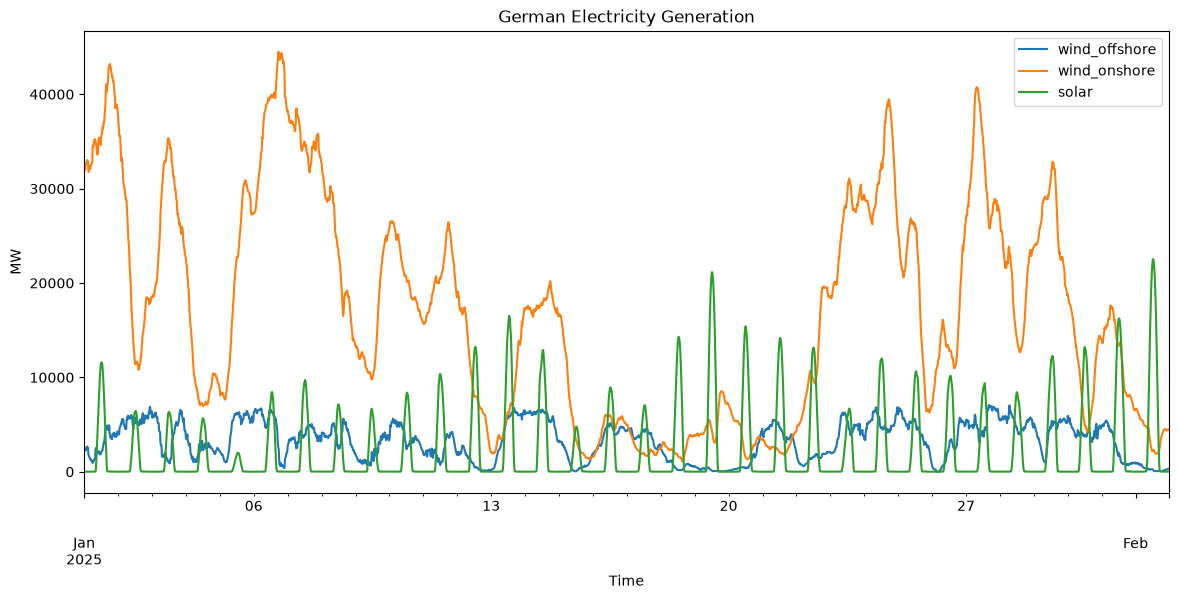

In [85]:
df_power.plot(
    x="timestamp",
    y=["wind_offshore", "wind_onshore", "solar"],
    figsize=(14, 6),
    title="German Electricity Generation"
)

plt.ylabel("MW")
plt.xlabel("Time")
plt.show()

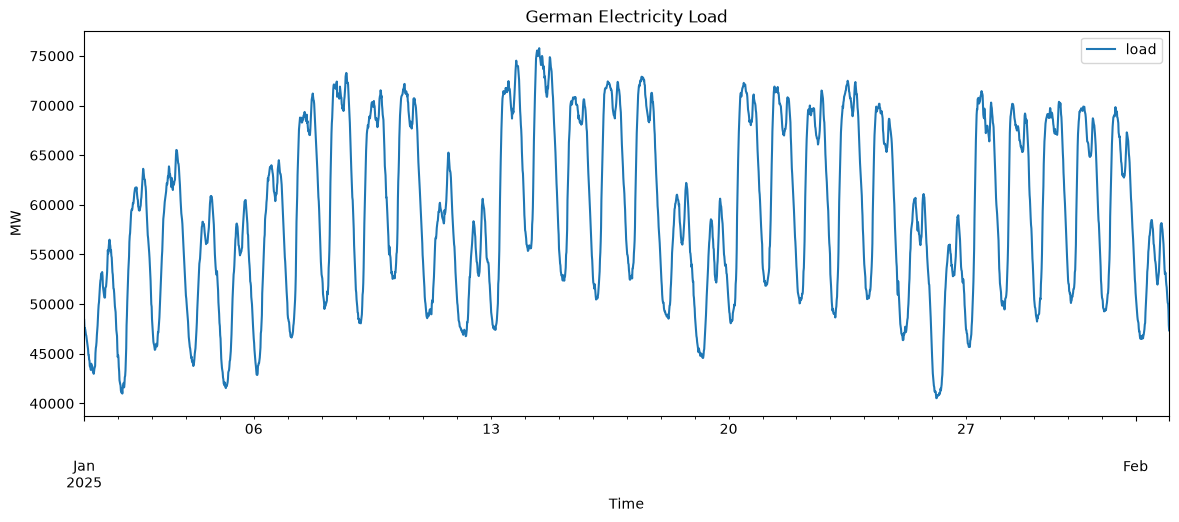

In [86]:
df_power.plot(
    x="timestamp",
    y="load",
    figsize=(14, 5),
    title="German Electricity Load"
)

plt.ylabel("MW")
plt.xlabel("Time")
plt.show()

# Viertelstunde auf stundenwerte aggregieren 

In [87]:
df_power_hourly = (
    df_power
    .set_index("timestamp")
    .resample("1h")
    .mean()
    .reset_index()
)

In [88]:
df_power_hourly.head()

,timestamp,wind_offshore,wind_onshore,solar,load
0,2025-01-01 00:00:00+01:00,2489.975,32014.575,0.000,47741.775
1,2025-01-01 01:00:00+01:00,2383.600,32642.025,0.000,46867.325
2,2025-01-01 02:00:00+01:00,2601.400,32882.650,0.000,45797.525
3,2025-01-01 03:00:00+01:00,1676.050,32015.150,0.000,44623.450
4,2025-01-01 04:00:00+01:00,1321.250,32246.625,4.325,43626.075


In [89]:
print(df_power_hourly.shape)

(768, 5)


In [90]:
print(
    df_power_hourly["timestamp"]
    .diff()
    .value_counts()
    .head()
)

timestamp
0 days 01:00:00    767
Name: count, dtype: int64


In [93]:
df_price["timestamp"] = df_price["timestamp"].dt.tz_convert(
    "Europe/Berlin"
)

In [94]:
print(df_price["timestamp"].head())
print(df_power_hourly["timestamp"].head())

0   2025-01-01 00:00:00+01:00
1   2025-01-01 01:00:00+01:00
2   2025-01-01 02:00:00+01:00
3   2025-01-01 03:00:00+01:00
4   2025-01-01 04:00:00+01:00
Name: timestamp, dtype: datetime64[s, Europe/Berlin]
0   2025-01-01 00:00:00+01:00
1   2025-01-01 01:00:00+01:00
2   2025-01-01 02:00:00+01:00
3   2025-01-01 03:00:00+01:00
4   2025-01-01 04:00:00+01:00
Name: timestamp, dtype: datetime64[s, Europe/Berlin]


In [95]:
df_power.head()

,timestamp,wind_offshore,wind_onshore,solar,load
0,2025-01-01 00:00:00+01:00,2403.3,32103.5,0.0,48412.1
1,2025-01-01 00:15:00+01:00,2588.6,31965.5,0.0,47534.7
2,2025-01-01 00:30:00+01:00,2529.9,31964.1,0.0,47573.4
3,2025-01-01 00:45:00+01:00,2438.1,32025.2,0.0,47446.9
4,2025-01-01 01:00:00+01:00,2241.6,32378.0,0.0,47200.3


In [96]:
df_power_hourly.head()

,timestamp,wind_offshore,wind_onshore,solar,load
0,2025-01-01 00:00:00+01:00,2489.975,32014.575,0.000,47741.775
1,2025-01-01 01:00:00+01:00,2383.600,32642.025,0.000,46867.325
2,2025-01-01 02:00:00+01:00,2601.400,32882.650,0.000,45797.525
3,2025-01-01 03:00:00+01:00,1676.050,32015.150,0.000,44623.450
4,2025-01-01 04:00:00+01:00,1321.250,32246.625,4.325,43626.075


In [97]:
df_power_hourly["wind"] = (
    df_power_hourly["wind_offshore"]
    + df_power_hourly["wind_onshore"]
)

In [98]:
df_energy = pd.merge(
    df_price,
    df_power_hourly,
    on="timestamp",
    how="inner"
)

In [99]:
df_energy.head()

,timestamp,price,wind_offshore,wind_onshore,solar,load,wind
0,2025-01-01 00:00:00+01:00,2.16,2489.975,32014.575,0.000,47741.775,34504.550
1,2025-01-01 01:00:00+01:00,1.60,2383.600,32642.025,0.000,46867.325,35025.625
2,2025-01-01 02:00:00+01:00,0.00,2601.400,32882.650,0.000,45797.525,35484.050
3,2025-01-01 03:00:00+01:00,-0.01,1676.050,32015.150,0.000,44623.450,33691.200
4,2025-01-01 04:00:00+01:00,-0.01,1321.250,32246.625,4.325,43626.075,33567.875


In [101]:
print("Preis-Daten:", len(df_price))
print("Power-Daten:", len(df_power_hourly))
print("Gemeinsamer Datensatz:", len(df_energy))
print(df_energy.isna().sum())
print(
    "Doppelte Zeitstempel:",
    df_energy["timestamp"].duplicated().sum()
)

Preis-Daten: 768
Power-Daten: 768
Gemeinsamer Datensatz: 768
timestamp        0
price            0
wind_offshore    0
wind_onshore     0
solar            0
load             0
wind             0
dtype: int64
Doppelte Zeitstempel: 0


# Auf längerem Zeitraum gehen 
01.01.2023 – 31.12.2025

In [102]:
price_params = {
    "bzn": "DE-LU",
    "start": "2023-01-01",
    "end": "2026-01-01"
}

response = requests.get(
    "https://api.energy-charts.info/price",
    params=price_params
)

print("Status:", response.status_code)
print("URL:", response.url)

Status: 200
URL: https://api.energy-charts.info/price?bzn=DE-LU&start=2023-01-01&end=2026-01-01


In [103]:
historical_price = response.json()

print(historical_price.keys())

dict_keys(['license_info', 'unix_seconds', 'price', 'unit', 'deprecated'])


In [104]:
print("Anzahl Zeitstempel:", len(historical_price["unix_seconds"]))
print("Anzahl Preise:", len(historical_price["price"]))
print("Einheit:", historical_price["unit"])

Anzahl Zeitstempel: 33027
Anzahl Preise: 33027
Einheit: EUR / MWh


In [105]:
price_timestamps = pd.to_datetime(
    historical_price["unix_seconds"],
    unit="s",
    utc=True
)

df_price = pd.DataFrame({
    "timestamp": price_timestamps,
    "price": historical_price["price"]
})

In [108]:
df_price.head()


,timestamp,price
0,2022-12-31 23:00:00+00:00,-5.17
1,2023-01-01 00:00:00+00:00,-1.07
2,2023-01-01 01:00:00+00:00,-1.47
3,2023-01-01 02:00:00+00:00,-5.08
4,2023-01-01 03:00:00+00:00,-4.49


In [109]:
print("Start:", df_price["timestamp"].min())
print("Ende:", df_price["timestamp"].max())

Start: 2022-12-31 23:00:00+00:00
Ende: 2026-01-01 22:45:00+00:00


In [110]:
print(
    df_price["timestamp"]
    .diff()
    .value_counts()
    .head()
)

timestamp
0 days 01:00:00    24095
0 days 00:15:00     8931
Name: count, dtype: int64


In [111]:
print("Shape:", df_price.shape)

print("\nMissing Values:")
print(df_price.isna().sum())

print("\nDoppelte Zeitstempel:")
print(df_price["timestamp"].duplicated().sum())

Shape: (33027, 2)

Missing Values:
timestamp    0
price        0
dtype: int64

Doppelte Zeitstempel:
0


In [112]:
print(response.status_code)

print("Anzahl Zeitstempel:",
      len(historical_price["unix_seconds"]))

print("Anzahl Preise:",
      len(historical_price["price"]))

print("Start:",
      df_price["timestamp"].min())

print("Ende:",
      df_price["timestamp"].max())

print(
    df_price["timestamp"]
    .diff()
    .value_counts()
    .head()
)

print("\nMissing Values:")
print(df_price.isna().sum())

print("\nDuplikate:",
      df_price["timestamp"].duplicated().sum())

200
Anzahl Zeitstempel: 33027
Anzahl Preise: 33027
Start: 2022-12-31 23:00:00+00:00
Ende: 2026-01-01 22:45:00+00:00
timestamp
0 days 01:00:00    24095
0 days 00:15:00     8931
Name: count, dtype: int64

Missing Values:
timestamp    0
price        0
dtype: int64

Duplikate: 0


24.095 × 1 Stunde \
 8.931 × 15 Minuten \
Die historische Preisreihe enthält unterschiedliche zeitliche Auflösungen.\
ab wann liefert die Energy-Charts-API Viertelstundenpreise und wie gehen wir damit um.
 

In [113]:
#bestimme den wechselpunkt 
df_price["time_diff"] = df_price["timestamp"].diff()

df_price.loc[
    df_price["time_diff"] != pd.Timedelta(hours=1),
    ["timestamp", "time_diff"]
].head(20)

,timestamp,time_diff
0,2022-12-31 23:00:00+00:00,NaT
24096,2025-09-30 22:15:00+00:00,0 days 00:15:00
24097,2025-09-30 22:30:00+00:00,0 days 00:15:00
24098,2025-09-30 22:45:00+00:00,0 days 00:15:00
24099,2025-09-30 23:00:00+00:00,0 days 00:15:00
24100,2025-09-30 23:15:00+00:00,0 days 00:15:00
24101,2025-09-30 23:30:00+00:00,0 days 00:15:00
24102,2025-09-30 23:45:00+00:00,0 days 00:15:00
24103,2025-10-01 00:00:00+00:00,0 days 00:15:00
24104,2025-10-01 00:15:00+00:00,0 days 00:15:00


In [115]:
first_15min = df_price.loc[
    df_price["time_diff"] == pd.Timedelta(minutes=15),
    "timestamp"
].min()

print("Erster 15-Minuten-Zeitpunkt:", first_15min)

Erster 15-Minuten-Zeitpunkt: 2025-09-30 22:15:00+00:00


In [116]:
first_hourly_after_15min = df_price.loc[
    (df_price["timestamp"] > first_15min) &
    (df_price["time_diff"] == pd.Timedelta(hours=1)),
    "timestamp"
].min()

print("Erster späterer Stunden-Zeitpunkt:", first_hourly_after_15min)

Erster späterer Stunden-Zeitpunkt: NaT


In [117]:
print(
    df_price[
        ["timestamp", "price", "time_diff"]
    ].head(20)
)

                   timestamp  price       time_diff
0  2022-12-31 23:00:00+00:00  -5.17             NaT
1  2023-01-01 00:00:00+00:00  -1.07 0 days 01:00:00
2  2023-01-01 01:00:00+00:00  -1.47 0 days 01:00:00
3  2023-01-01 02:00:00+00:00  -5.08 0 days 01:00:00
4  2023-01-01 03:00:00+00:00  -4.49 0 days 01:00:00
5  2023-01-01 04:00:00+00:00  -5.40 0 days 01:00:00
6  2023-01-01 05:00:00+00:00  -5.02 0 days 01:00:00
7  2023-01-01 06:00:00+00:00  -1.30 0 days 01:00:00
8  2023-01-01 07:00:00+00:00  -1.44 0 days 01:00:00
9  2023-01-01 08:00:00+00:00  -1.09 0 days 01:00:00
10 2023-01-01 09:00:00+00:00  -1.07 0 days 01:00:00
11 2023-01-01 10:00:00+00:00  -1.07 0 days 01:00:00
12 2023-01-01 11:00:00+00:00  -0.79 0 days 01:00:00
13 2023-01-01 12:00:00+00:00  -0.27 0 days 01:00:00
14 2023-01-01 13:00:00+00:00   0.85 0 days 01:00:00
15 2023-01-01 14:00:00+00:00  23.53 0 days 01:00:00
16 2023-01-01 15:00:00+00:00  36.54 0 days 01:00:00
17 2023-01-01 16:00:00+00:00  46.03 0 days 01:00:00
18 2023-01-0

In [118]:
print(
    df_price[
        ["timestamp", "price", "time_diff"]
    ].tail(20)
)

                      timestamp  price       time_diff
33007 2026-01-01 18:00:00+00:00  28.96 0 days 00:15:00
33008 2026-01-01 18:15:00+00:00  18.27 0 days 00:15:00
33009 2026-01-01 18:30:00+00:00  12.58 0 days 00:15:00
33010 2026-01-01 18:45:00+00:00  12.56 0 days 00:15:00
33011 2026-01-01 19:00:00+00:00  12.53 0 days 00:15:00
33012 2026-01-01 19:15:00+00:00  10.05 0 days 00:15:00
33013 2026-01-01 19:30:00+00:00  10.08 0 days 00:15:00
33014 2026-01-01 19:45:00+00:00   7.51 0 days 00:15:00
33015 2026-01-01 20:00:00+00:00  10.01 0 days 00:15:00
33016 2026-01-01 20:15:00+00:00  10.10 0 days 00:15:00
33017 2026-01-01 20:30:00+00:00   9.86 0 days 00:15:00
33018 2026-01-01 20:45:00+00:00   5.83 0 days 00:15:00
33019 2026-01-01 21:00:00+00:00  15.28 0 days 00:15:00
33020 2026-01-01 21:15:00+00:00   9.61 0 days 00:15:00
33021 2026-01-01 21:30:00+00:00   4.50 0 days 00:15:00
33022 2026-01-01 21:45:00+00:00   0.10 0 days 00:15:00
33023 2026-01-01 22:00:00+00:00   1.14 0 days 00:15:00
33024 2026

In [119]:
idx = df_price["timestamp"].searchsorted(first_15min)

print(
    df_price.iloc[idx-10:idx+20]
)

                      timestamp   price       time_diff
24086 2025-09-30 13:00:00+00:00   96.80 0 days 01:00:00
24087 2025-09-30 14:00:00+00:00  104.03 0 days 01:00:00
24088 2025-09-30 15:00:00+00:00  142.64 0 days 01:00:00
24089 2025-09-30 16:00:00+00:00  294.54 0 days 01:00:00
24090 2025-09-30 17:00:00+00:00  357.77 0 days 01:00:00
24091 2025-09-30 18:00:00+00:00  147.28 0 days 01:00:00
24092 2025-09-30 19:00:00+00:00  116.04 0 days 01:00:00
24093 2025-09-30 20:00:00+00:00  101.63 0 days 01:00:00
24094 2025-09-30 21:00:00+00:00   92.54 0 days 01:00:00
24095 2025-09-30 22:00:00+00:00  102.60 0 days 01:00:00
24096 2025-09-30 22:15:00+00:00   92.24 0 days 00:15:00
24097 2025-09-30 22:30:00+00:00   86.03 0 days 00:15:00
24098 2025-09-30 22:45:00+00:00   85.39 0 days 00:15:00
24099 2025-09-30 23:00:00+00:00   89.99 0 days 00:15:00
24100 2025-09-30 23:15:00+00:00   86.03 0 days 00:15:00
24101 2025-09-30 23:30:00+00:00   85.03 0 days 00:15:00
24102 2025-09-30 23:45:00+00:00   84.09 0 days 0

In [122]:
df_price["time_diff"] = df_price["timestamp"].diff()

first_15min = df_price.loc[
    df_price["time_diff"] == pd.Timedelta(minutes=15),
    "timestamp"
].min()

print("Erster 15-Minuten-Zeitpunkt:", first_15min)

print(
    df_price[
        ["timestamp", "price", "time_diff"]
    ].iloc[
        df_price["timestamp"].searchsorted(first_15min)-10:
        df_price["timestamp"].searchsorted(first_15min)+20
    ]
)

print(
    df_price.groupby(
        df_price["timestamp"].dt.year
    )["time_diff"].value_counts()
)

Erster 15-Minuten-Zeitpunkt: 2025-09-30 22:15:00+00:00
                      timestamp   price       time_diff
24086 2025-09-30 13:00:00+00:00   96.80 0 days 01:00:00
24087 2025-09-30 14:00:00+00:00  104.03 0 days 01:00:00
24088 2025-09-30 15:00:00+00:00  142.64 0 days 01:00:00
24089 2025-09-30 16:00:00+00:00  294.54 0 days 01:00:00
24090 2025-09-30 17:00:00+00:00  357.77 0 days 01:00:00
24091 2025-09-30 18:00:00+00:00  147.28 0 days 01:00:00
24092 2025-09-30 19:00:00+00:00  116.04 0 days 01:00:00
24093 2025-09-30 20:00:00+00:00  101.63 0 days 01:00:00
24094 2025-09-30 21:00:00+00:00   92.54 0 days 01:00:00
24095 2025-09-30 22:00:00+00:00  102.60 0 days 01:00:00
24096 2025-09-30 22:15:00+00:00   92.24 0 days 00:15:00
24097 2025-09-30 22:30:00+00:00   86.03 0 days 00:15:00
24098 2025-09-30 22:45:00+00:00   85.39 0 days 00:15:00
24099 2025-09-30 23:00:00+00:00   89.99 0 days 00:15:00
24100 2025-09-30 23:15:00+00:00   86.03 0 days 00:15:00
24101 2025-09-30 23:30:00+00:00   85.03 0 days 00

In [123]:
df_price = df_price.drop(columns="time_diff")

In [124]:
df_price["timestamp"] = (
    df_price["timestamp"]
    .dt.tz_convert("Europe/Berlin")
)

In [125]:
print(df_price.head())

                  timestamp  price
0 2023-01-01 00:00:00+01:00  -5.17
1 2023-01-01 01:00:00+01:00  -1.07
2 2023-01-01 02:00:00+01:00  -1.47
3 2023-01-01 03:00:00+01:00  -5.08
4 2023-01-01 04:00:00+01:00  -4.49


In [126]:
# Wenn innerhalb einer Stunde mehrere Preisbeobachtungen existieren, berechne deren Mittelwert.
df_price_hourly = (
    df_price
    .set_index("timestamp")
    .resample("1h")
    .agg({
        "price": "mean"
    })
    .reset_index()
)

In [127]:
print(df_price_hourly.shape)
print(df_price_hourly.head())
print(df_price_hourly.tail())

(26328, 2)
                  timestamp  price
0 2023-01-01 00:00:00+01:00  -5.17
1 2023-01-01 01:00:00+01:00  -1.07
2 2023-01-01 02:00:00+01:00  -1.47
3 2023-01-01 03:00:00+01:00  -5.08
4 2023-01-01 04:00:00+01:00  -4.49
                      timestamp    price
26323 2026-01-01 19:00:00+01:00  18.0925
26324 2026-01-01 20:00:00+01:00  10.0425
26325 2026-01-01 21:00:00+01:00   8.9500
26326 2026-01-01 22:00:00+01:00   7.3725
26327 2026-01-01 23:00:00+01:00   0.2850


In [129]:
print(
    df_price_hourly["timestamp"]
    .diff()
    .value_counts()
    .head()
)
print(df_price_hourly.isna().sum())

timestamp
0 days 01:00:00    26327
Name: count, dtype: int64
timestamp    0
price        0
dtype: int64


# Public power für 2023 - 2025 

In [130]:
power_params = {
    "start": "2023-01-01",
    "end": "2026-01-01"
}

response_power = requests.get(
    "https://api.energy-charts.info/public_power",
    params=power_params
)

print("Status:", response_power.status_code)
print("URL:", response_power.url)

Status: 200
URL: https://api.energy-charts.info/public_power?start=2023-01-01&end=2026-01-01


In [131]:
historical_power = response_power.json()

print(historical_power.keys())
print("Anzahl Zeitstempel:",
      len(historical_power["unix_seconds"]))

dict_keys(['unix_seconds', 'production_types', 'deprecated'])
Anzahl Zeitstempel: 105312


In [132]:
power_timestamps = pd.to_datetime(
    historical_power["unix_seconds"],
    unit="s",
    utc=True
)

print("Start:", power_timestamps.min())
print("Ende:", power_timestamps.max())

print(
    power_timestamps.diff()
    .value_counts()
    .head()
)

Start: 2022-12-31 23:00:00+00:00
Ende: 2026-01-01 22:45:00+00:00
0 days 00:15:00    105311
Name: count, dtype: int64


In [133]:
for production_type in historical_power["production_types"]:
    print(production_type["name"])

Hydro pumped storage consumption
Cross border electricity trading
Nuclear
Hydro Run-of-River
Biomass
Fossil brown coal / lignite
Fossil hard coal
Fossil oil
Fossil coal-derived gas
Fossil gas
Geothermal
Hydro water reservoir
Hydro pumped storage
Others
Waste
Wind offshore
Wind onshore
Solar
Load
Residual load
Renewable share of load
Renewable share of generation


In [134]:
power_timestamps = pd.to_datetime(
    historical_power["unix_seconds"],
    unit="s",
    utc=True
)

In [135]:
df_power = pd.DataFrame({
    "timestamp": power_timestamps
})

In [136]:
for production_type in historical_power["production_types"]:
    
    name = production_type["name"]
    
    if name == "Wind offshore":
        df_power["wind_offshore"] = production_type["data"]
        
    elif name == "Wind onshore":
        df_power["wind_onshore"] = production_type["data"]
        
    elif name == "Solar":
        df_power["solar"] = production_type["data"]
        
    elif name == "Load":
        df_power["load"] = production_type["data"]

In [137]:
df_power.head()

,timestamp,wind_offshore,wind_onshore,solar,load
0,2022-12-31 23:00:00+00:00,2739.0,27260.9,0.0,38691.8
1,2022-12-31 23:15:00+00:00,2975.6,27311.5,0.0,38374.2
2,2022-12-31 23:30:00+00:00,3269.6,27699.4,0.0,38248.0
3,2022-12-31 23:45:00+00:00,3259.5,27170.0,0.0,38070.2
4,2023-01-01 00:00:00+00:00,3144.1,27853.6,0.0,37733.4


In [138]:
print(df_power.shape)

print("\nMissing Values:")
print(df_power.isna().sum())

print("\nDoppelte Zeitstempel:")
print(df_power["timestamp"].duplicated().sum())

(105312, 5)

Missing Values:
timestamp        0
wind_offshore    0
wind_onshore     0
solar            0
load             0
dtype: int64

Doppelte Zeitstempel:
0


In [139]:
df_power["timestamp"] = (
    df_power["timestamp"]
    .dt.tz_convert("Europe/Berlin")
)

In [140]:
df_power_hourly = (
    df_power
    .set_index("timestamp")
    .resample("1h")
    .mean()
    .reset_index()
)

In [141]:
df_power_hourly["wind"] = (
    df_power_hourly["wind_offshore"]
    + df_power_hourly["wind_onshore"]
)

In [142]:
print(df_power_hourly.shape)

print(
    df_power_hourly["timestamp"]
    .diff()
    .value_counts()
    .head()
)

(26328, 6)
timestamp
0 days 01:00:00    26327
Name: count, dtype: int64


In [143]:
print(df_power_hourly.head())
print(df_power_hourly.tail())

                  timestamp  wind_offshore  wind_onshore  solar       load  \
0 2023-01-01 00:00:00+01:00       3060.925     27360.450   0.00  38346.050   
1 2023-01-01 01:00:00+01:00       3588.425     27965.775   0.00  37777.200   
2 2023-01-01 02:00:00+01:00       3844.575     27897.050   0.00  36939.925   
3 2023-01-01 03:00:00+01:00       3465.125     25986.475   0.00  35932.375   
4 2023-01-01 04:00:00+01:00       3464.275     25462.150   1.05  35486.250   

        wind  
0  30421.375  
1  31554.200  
2  31741.625  
3  29451.600  
4  28926.425  
                      timestamp  wind_offshore  wind_onshore   solar  \
26323 2026-01-01 19:00:00+01:00       4600.625      42572.70  28.875   
26324 2026-01-01 20:00:00+01:00       5576.200      43242.10  19.800   
26325 2026-01-01 21:00:00+01:00       5566.900      42128.80  15.075   
26326 2026-01-01 22:00:00+01:00       4941.750      40031.35   0.000   
26327 2026-01-01 23:00:00+01:00       4033.750      40207.55   0.000   

        

In [144]:
print(df_power_hourly.isna().sum())

timestamp        0
wind_offshore    0
wind_onshore     0
solar            0
load             0
wind             0
dtype: int64


In [145]:
df_energy = pd.merge(
    df_price_hourly,
    df_power_hourly,
    on="timestamp",
    how="inner"
)

In [146]:
print(df_energy.shape)
print(df_energy.head())
print(df_energy.isna().sum())
print(
    "Duplikate:",
    df_energy["timestamp"].duplicated().sum()
)

(26328, 7)
                  timestamp  price  wind_offshore  wind_onshore  solar  \
0 2023-01-01 00:00:00+01:00  -5.17       3060.925     27360.450   0.00   
1 2023-01-01 01:00:00+01:00  -1.07       3588.425     27965.775   0.00   
2 2023-01-01 02:00:00+01:00  -1.47       3844.575     27897.050   0.00   
3 2023-01-01 03:00:00+01:00  -5.08       3465.125     25986.475   0.00   
4 2023-01-01 04:00:00+01:00  -4.49       3464.275     25462.150   1.05   

        load       wind  
0  38346.050  30421.375  
1  37777.200  31554.200  
2  36939.925  31741.625  
3  35932.375  29451.600  
4  35486.250  28926.425  
timestamp        0
price            0
wind_offshore    0
wind_onshore     0
solar            0
load             0
wind             0
dtype: int64
Duplikate: 0


In [147]:
df_price.to_csv(
    "../data/raw/price_2023_2025.csv",
    index=False
)

df_power.to_csv(
    "../data/raw/power_2023_2025.csv",
    index=False
)

In [148]:
df_energy.to_csv(
    "../data/processed/energy_hourly_2023_2025.csv",
    index=False
)

In [150]:
df_energy.describe().round(2)

,price,wind_offshore,wind_onshore,solar,load,wind
count,26328.00,26328.00,26328.00,26328.00,26328.00,26328.00
mean,87.59,2863.70,12632.97,6980.32,52828.64,15496.67
std,51.35,1931.91,9754.65,10653.45,9128.71,11006.35
min,-500.00,0.00,45.82,0.00,30902.68,45.85
25%,65.00,1127.55,4856.08,0.60,45328.72,6449.06
50%,90.05,2615.89,10024.76,225.29,52873.38,12923.95
75%,112.94,4475.33,18298.82,11240.26,59705.43,22532.48
max,936.28,8237.78,47795.28,49713.88,75635.23,52173.80


In [151]:
df_energy["price"].describe()

count    26328.000000
mean        87.590362
std         51.354420
min       -500.000000
25%         65.000000
50%         90.050000
75%        112.940000
max        936.280000
Name: price, dtype: float64

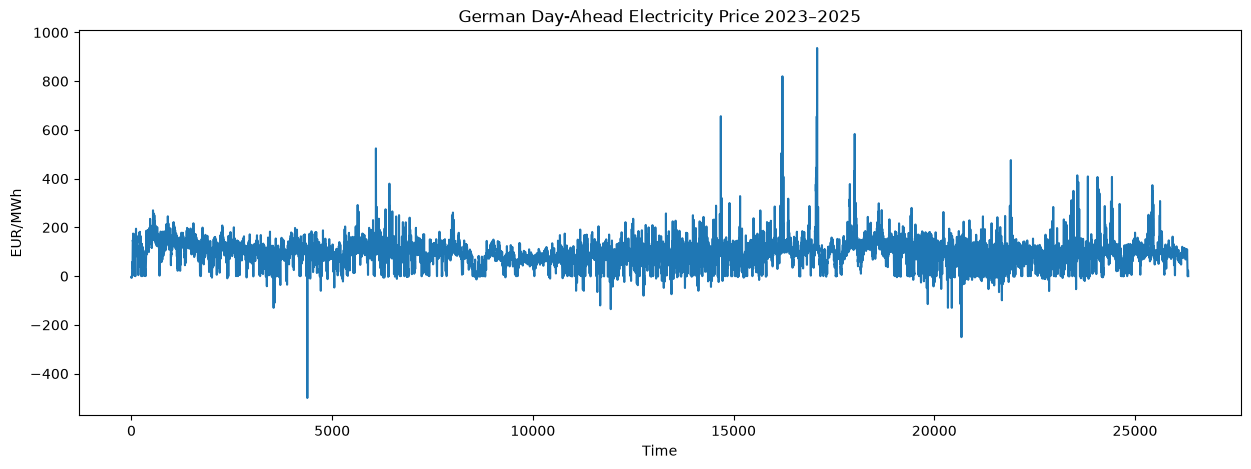

In [152]:
df_energy["price"].plot(
    figsize=(15, 5),
    title="German Day-Ahead Electricity Price 2023–2025"
)

plt.ylabel("EUR/MWh")
plt.xlabel("Time")
plt.show()